In [2]:
from pathlib import Path
from src.data.loader import load_orders, load_order_items, load_web_traffic, load_inventory, load_sales
from src.features.build import build_daily_one_row_per_day, drop_columns
from src.utils.plot_features import plot_correlation_heatmap

root = Path.cwd()

orders_df = load_orders()
order_items_df = load_order_items()
web_traffic_df = load_web_traffic()
inventory_df = load_inventory()
sales_df = load_sales()

daily_df = build_daily_one_row_per_day(
    orders_df=orders_df,
    order_items_df=order_items_df,
    web_traffic_df=web_traffic_df,
    inventory_df=inventory_df,
    sales_df=sales_df,
)

daily_df = drop_columns(daily_df, ["same_day_delivery_orders", "weekend_order_share","same_day_delivery_rate", "inv_reorder_products"])

print("shape:", daily_df.shape)
print("duplicated date rows:", int(daily_df["date"].duplicated().sum()))
print("date range:", daily_df["date"].min(), "->", daily_df["date"].max())

print("\ncolumns:")
for i, col in enumerate(daily_df.columns, start=1):
    print(f"{i:02d}. {col}")

from src.utils.plot_features import build_daily, plot_by_year, plot_all_year, plot_overlay

shape: (3833, 429)
duplicated date rows: 0
date range: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00

columns:
01. date
02. Revenue
03. COGS
04. orders_count
05. customers_count
06. returned_orders
07. cancelled_orders
08. delivered_orders
09. payment_value_total
10. installments_mean
11. shipping_fee_total
12. shipping_lead_days_mean
13. shipping_lead_days_p90
14. fulfillment_days_mean
15. payment_value_mean
16. payment_value_std
17. payment_value_median
18. customer_tenure_days_mean
19. customer_tenure_days_p90
20. weekend_orders
21. same_day_ship_orders
22. return_rate_orders
23. cancel_rate_orders
24. same_day_ship_rate
25. items_count
26. quantity_sold
27. gross_merch_value
28. discount_total
29. net_merch_value
30. list_merch_value
31. items_cogs_total
32. unique_products_sold
33. unit_price_mean
34. unit_price_std
35. promo_1_active_lines
36. promo_2_active_lines
37. stackable_promo_lines
38. refund_amount_total
39. return_quantity_total
40. rating_mean
41. promo_1_usage_count
42. 

In [3]:
# Feature Classification
import re
import pandas as pd

all_cols = list(daily_df.columns)

# 1. ID / index
id_cols = ['date']

# 2. Target
target_cols = ['Revenue', 'COGS']

# 3. Temporal
temporal_cols = [c for c in all_cols if c in {
    'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year',
    'is_weekend',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
}]

# 4. Order & Fulfilment (raw counts / means)
order_raw = {
    'orders_count', 'customers_count', 'returned_orders', 'cancelled_orders',
    'delivered_orders', 'payment_value_total', 'installments_mean',
    'shipping_fee_total', 'shipping_lead_days_mean', 'shipping_lead_days_p90',
    'fulfillment_days_mean', 'payment_value_mean', 'payment_value_std',
    'payment_value_median', 'customer_tenure_days_mean',
    'customer_tenure_days_p90', 'weekend_orders', 'same_day_ship_orders',
    'same_day_delivery_orders', 'return_rate_orders', 'cancel_rate_orders',
    'weekend_order_share', 'same_day_ship_rate', 'same_day_delivery_rate',
    'shipped_orders_count', 'shipped_fee_total', 'delivered_orders_count',
}
order_cols = [c for c in all_cols if c in order_raw]

# 5. Product & Pricing (raw)
product_raw = {
    'items_count', 'quantity_sold', 'gross_merch_value',
    'discount_total', 'net_merch_value', 'list_merch_value',
    'items_cogs_total', 'unique_products_sold', 'unit_price_mean',
    'unit_price_std', 'refund_amount_total', 'return_quantity_total',
    'returned_items_events', 'returned_items_quantity', 'returned_refund_value',
}
product_cols = [c for c in all_cols if c in product_raw]

# 6. Promo (raw counts + type/channel share)
promo_raw = {
    'promo_1_active_lines', 'promo_2_active_lines', 'stackable_promo_lines',
    'promo_1_usage_count', 'promo_2_usage_count',
    'promo_1_discount_value_mean', 'promo_2_discount_value_mean',
    'promo_1_min_order_value_mean', 'promo_2_min_order_value_mean',
}
promo_cols = [c for c in all_cols
              if c in promo_raw
              or re.match(r'promo_(type|channel)_', c)]

# 7. Customer & Demographic share
customer_prefixes = (
    'payment_method_share_', 'device_share_', 'order_source_share_',
    'acquisition_share_', 'gender_share_', 'age_group_share_',
)
customer_cols = [c for c in all_cols if c.startswith(customer_prefixes)]

# 8. Product Mix share
product_mix_cols = [c for c in all_cols
                    if c.startswith('item_category_share_')
                    or c.startswith('item_segment_share_')]

# 9. Review & Satisfaction
review_raw = {'rating_mean', 'reviews_count', 'reviews_rating_mean', 'reviews_rating_std'}
review_cols = [c for c in all_cols if c in review_raw]

# 10. Web Traffic
web_raw = {
    'sessions', 'unique_visitors', 'page_views', 'bounce_rate',
    'avg_session_duration_sec',
}
web_cols = [c for c in all_cols
            if c in web_raw or c.startswith('traffic_source_share_')]

# 11. Inventory
inventory_cols = [c for c in all_cols if c.startswith('inv_')]

# 12. Engineered Ratios / Composite
engineered_raw = {
    'gross_margin', 'gross_margin_ratio', 'aov_revenue', 'units_per_order',
    'discount_rate', 'effective_discount_rate', 'refund_rate',
    'returns_event_rate', 'returns_quantity_rate', 'refund_to_revenue_rate',
    'pages_per_session', 'sessions_per_visitor', 'pages_per_visitor',
    'revenue_per_session', 'conversion_rate', 'delivery_throughput_rate',
    'checkout_efficiency', 'aov_true', 'avg_item_price', 'basket_size',
    'orders_per_customer', 'product_diversity', 'refund_per_order',
    'return_items_ratio', 'discount_per_order', 'discount_efficiency',
    'stackable_promo_rate', 'demand_supply_ratio', 'inventory_pressure',
    'inventory_turnover_proxy', 'review_coverage_rate', 'returning_users',
    'returning_rate', 'engagement_score', 'quality_sessions',
    'loyal_engagement', 'order_loss_rate', 'satisfaction_demand',
    'promo_intensity', 'promo_active_line_rate', 'engaged_sessions',
    'stock_availability', 'inventory_gap', 'revenue_driver', 'quality_revenue',
    'demand_strength', 'review_sentiment_score', 'revenue_to_cogs_items_gap',
}
engineered_cols = [c for c in all_cols if c in engineered_raw]

# 13. Lag / Rolling / Diff temporal features
_lag_re = re.compile(r'_(lag_|roll_mean_|roll_std_|diff_|pct_change_)')
lag_cols = [c for c in all_cols if _lag_re.search(c)]

# ---- catch-all ----
classified = set(
    id_cols + target_cols + temporal_cols + order_cols + product_cols
    + promo_cols + customer_cols + product_mix_cols + review_cols
    + web_cols + inventory_cols + engineered_cols + lag_cols
)
unclassified_cols = [c for c in all_cols if c not in classified]

# ---- summary ----
groups = {
    'ID':                     id_cols,
    'Target':                 target_cols,
    'Temporal':               temporal_cols,
    'Order & Fulfilment':     order_cols,
    'Product & Pricing':      product_cols,
    'Promo':                  promo_cols,
    'Customer & Demographic': customer_cols,
    'Product Mix Share':      product_mix_cols,
    'Review & Satisfaction':  review_cols,
    'Web Traffic':            web_cols,
    'Inventory':              inventory_cols,
    'Engineered Ratios':      engineered_cols,
    'Lag / Rolling / Diff':   lag_cols,
    'Unclassified':           unclassified_cols,
}

rows = []
for g, cols in groups.items():
    rows.append({
        'Group':   g,
        'Count':   len(cols),
        'Examples': ', '.join(cols[:4]) + (' ...' if len(cols) > 4 else ''),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
print(f'\nTotal features (excl. ID & target): {len(all_cols) - len(id_cols) - len(target_cols)}')
print(f'Total columns                      : {len(all_cols)}')

                 Group  Count                                                                                                                           Examples
                    ID      1                                                                                                                               date
                Target      2                                                                                                                      Revenue, COGS
              Temporal     13                                                                                                  year, month, day, day_of_week ...
    Order & Fulfilment     24                                                               orders_count, customers_count, returned_orders, cancelled_orders ...
     Product & Pricing     15                                                                  items_count, quantity_sold, gross_merch_value, discount_total ...
                 Promo     22     

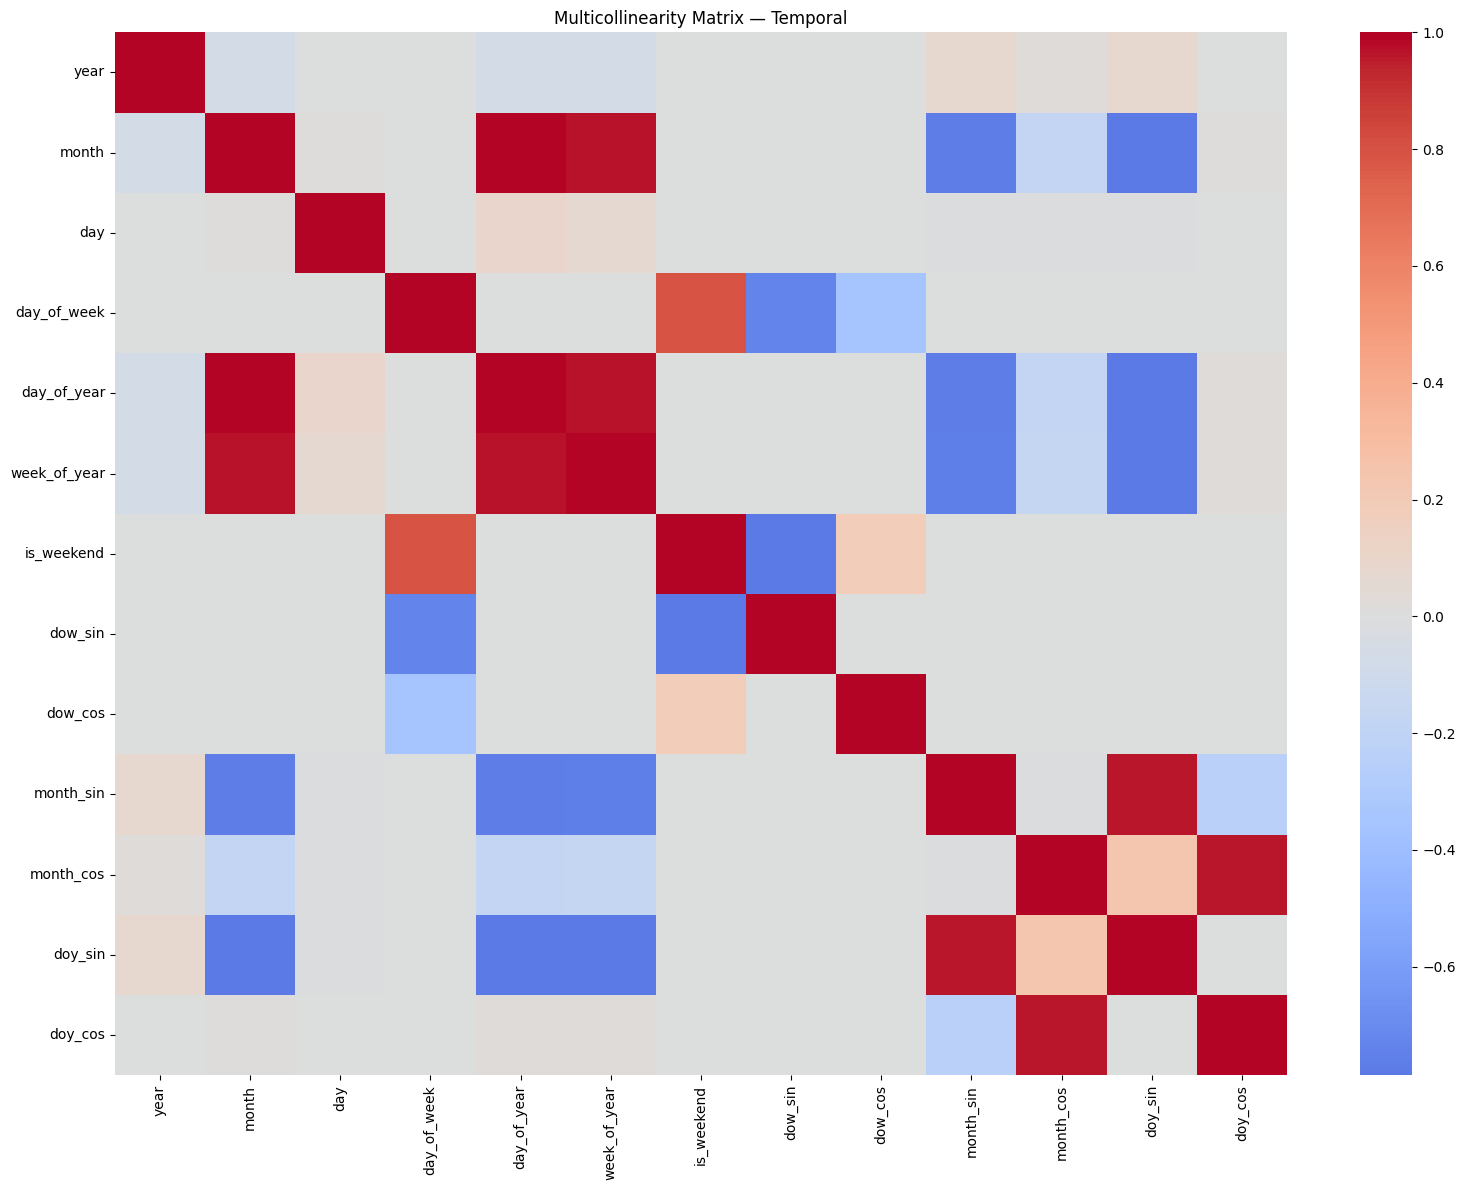

In [18]:
plot_correlation_heatmap(daily_df, temporal_cols, group_label="Temporal")


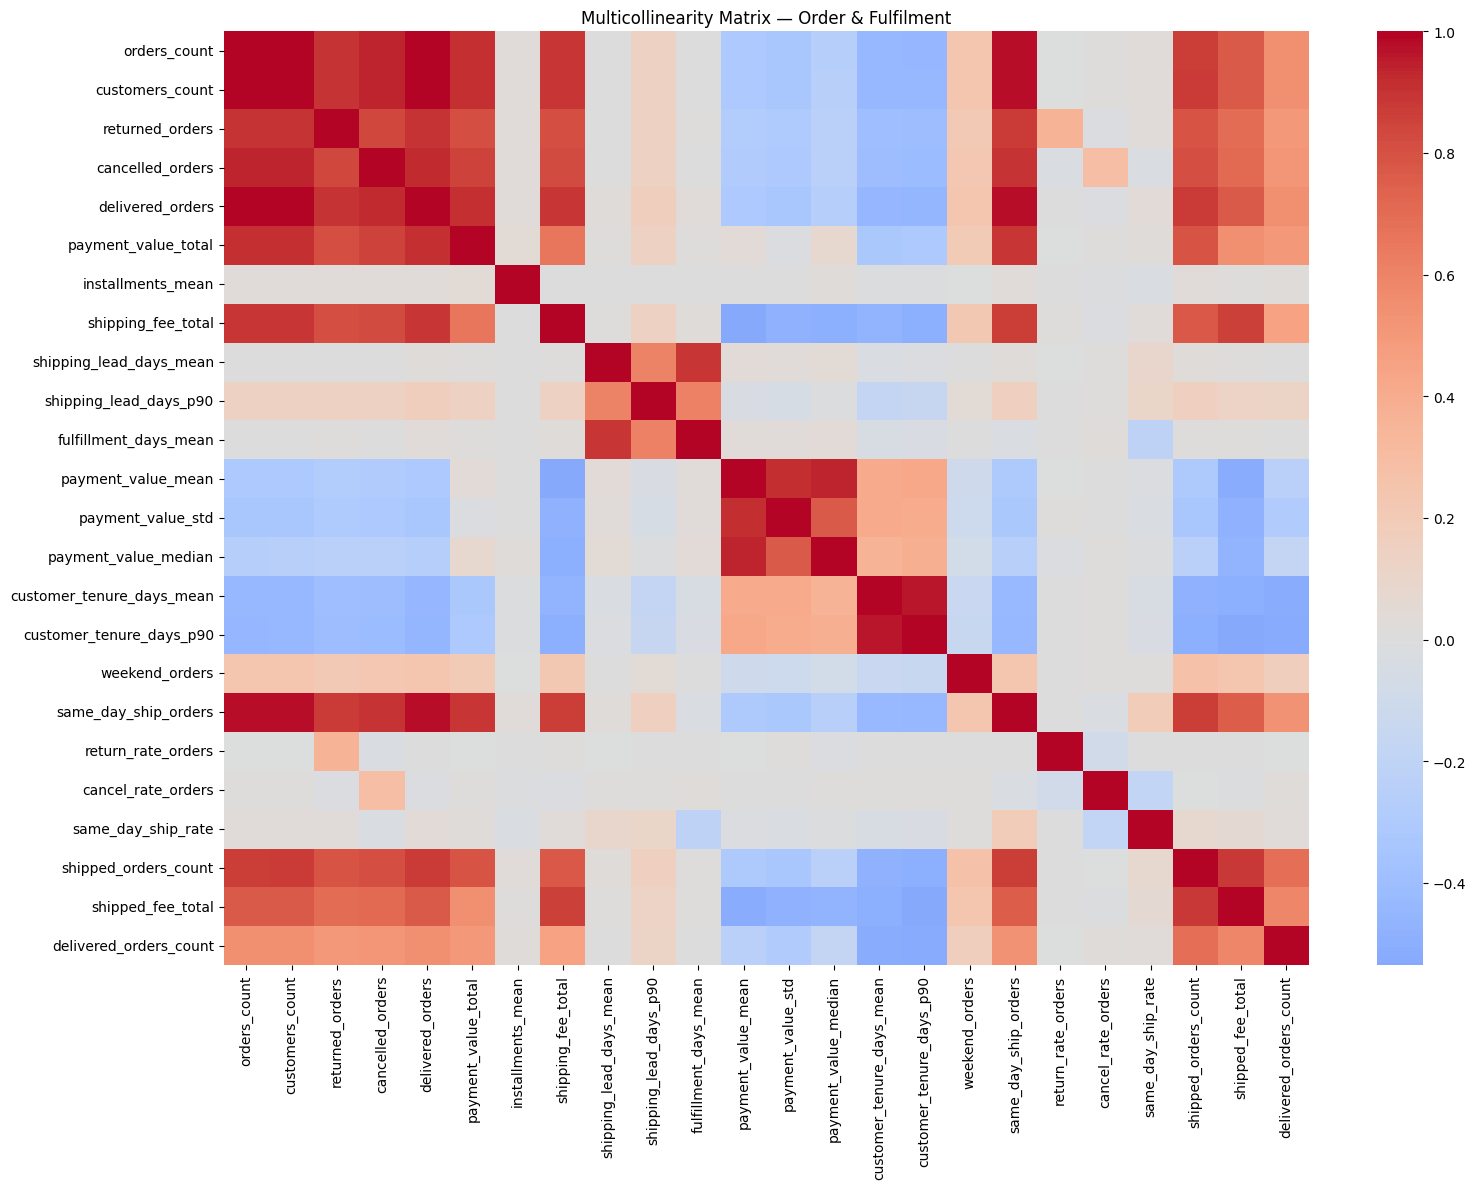

In [5]:
plot_correlation_heatmap(daily_df, order_cols, group_label="Order & Fulfilment")


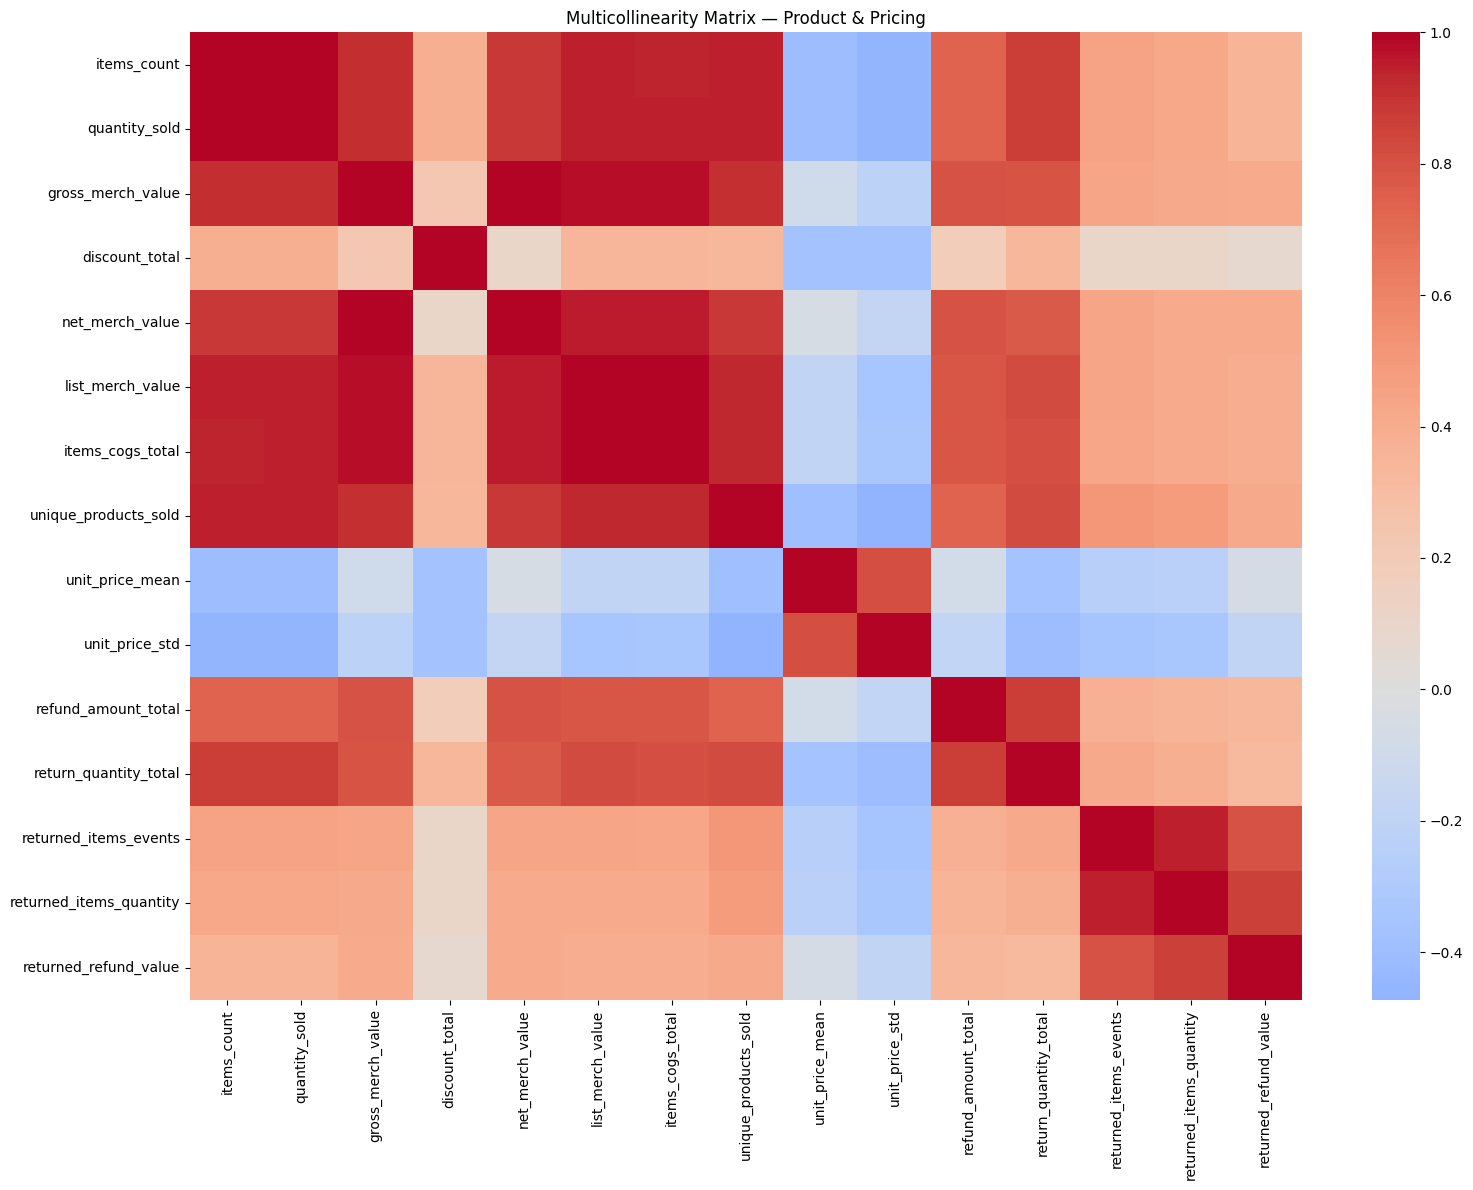

In [6]:
plot_correlation_heatmap(daily_df, product_cols, group_label="Product & Pricing")


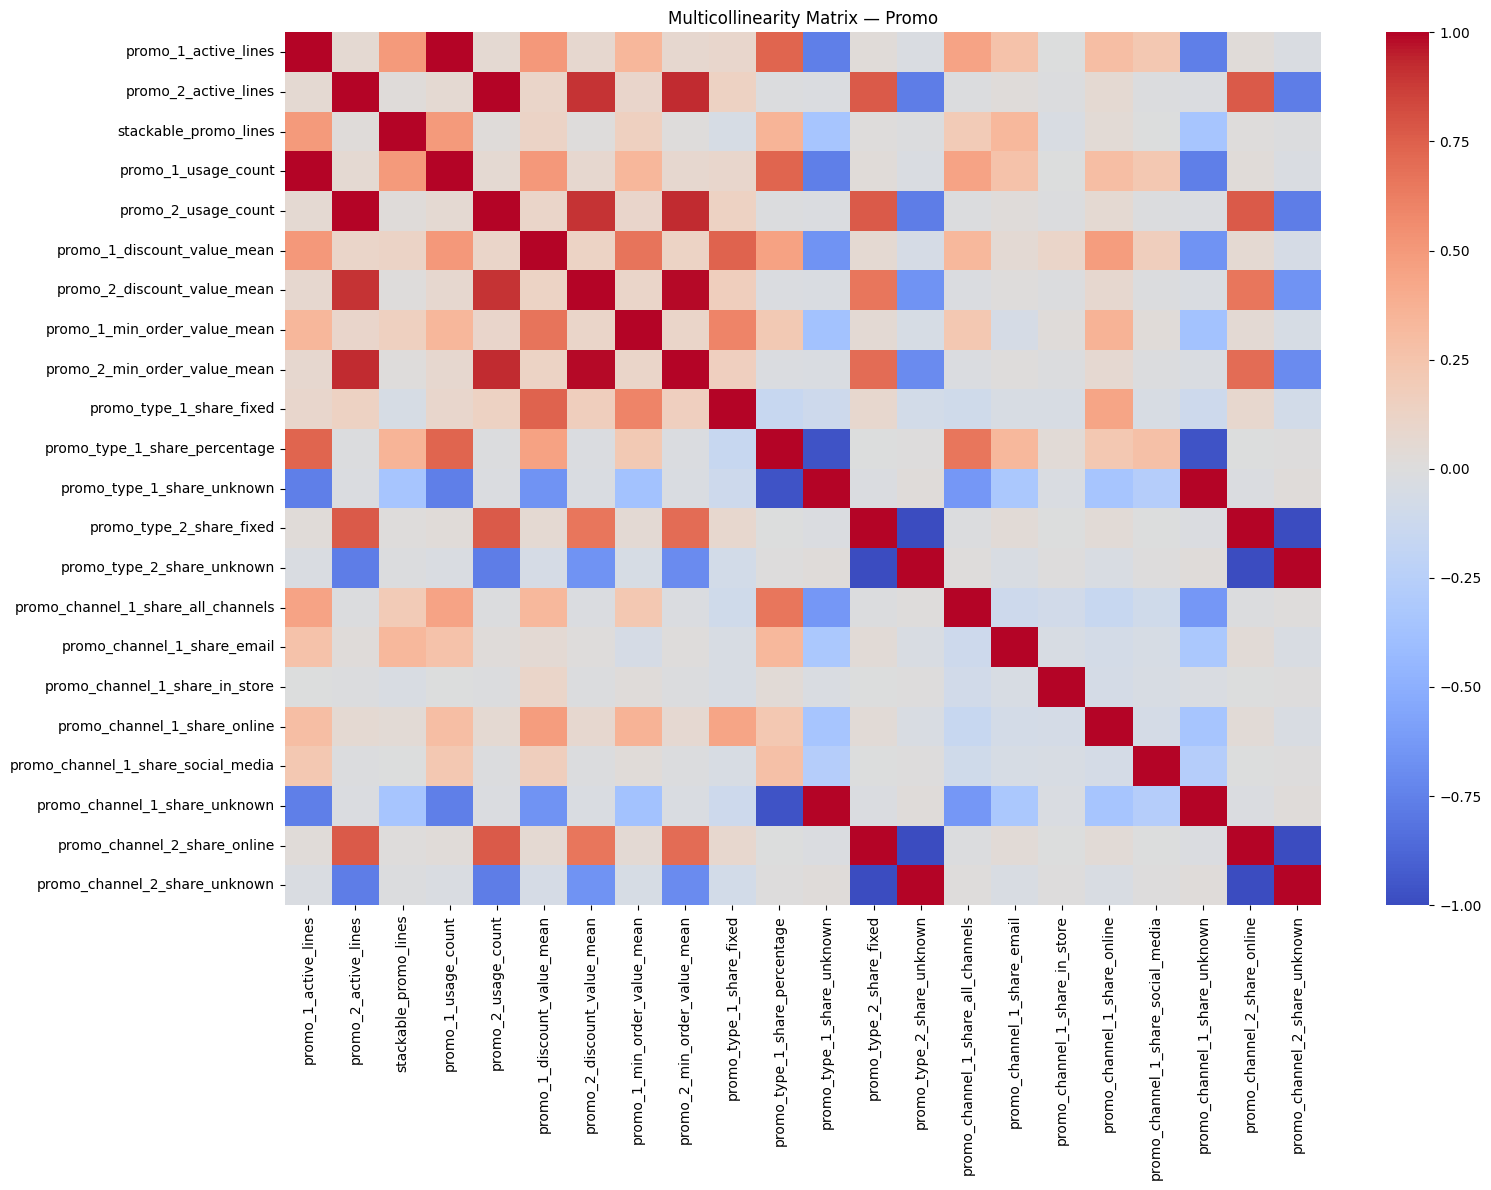

In [7]:
plot_correlation_heatmap(daily_df, promo_cols, group_label="Promo")


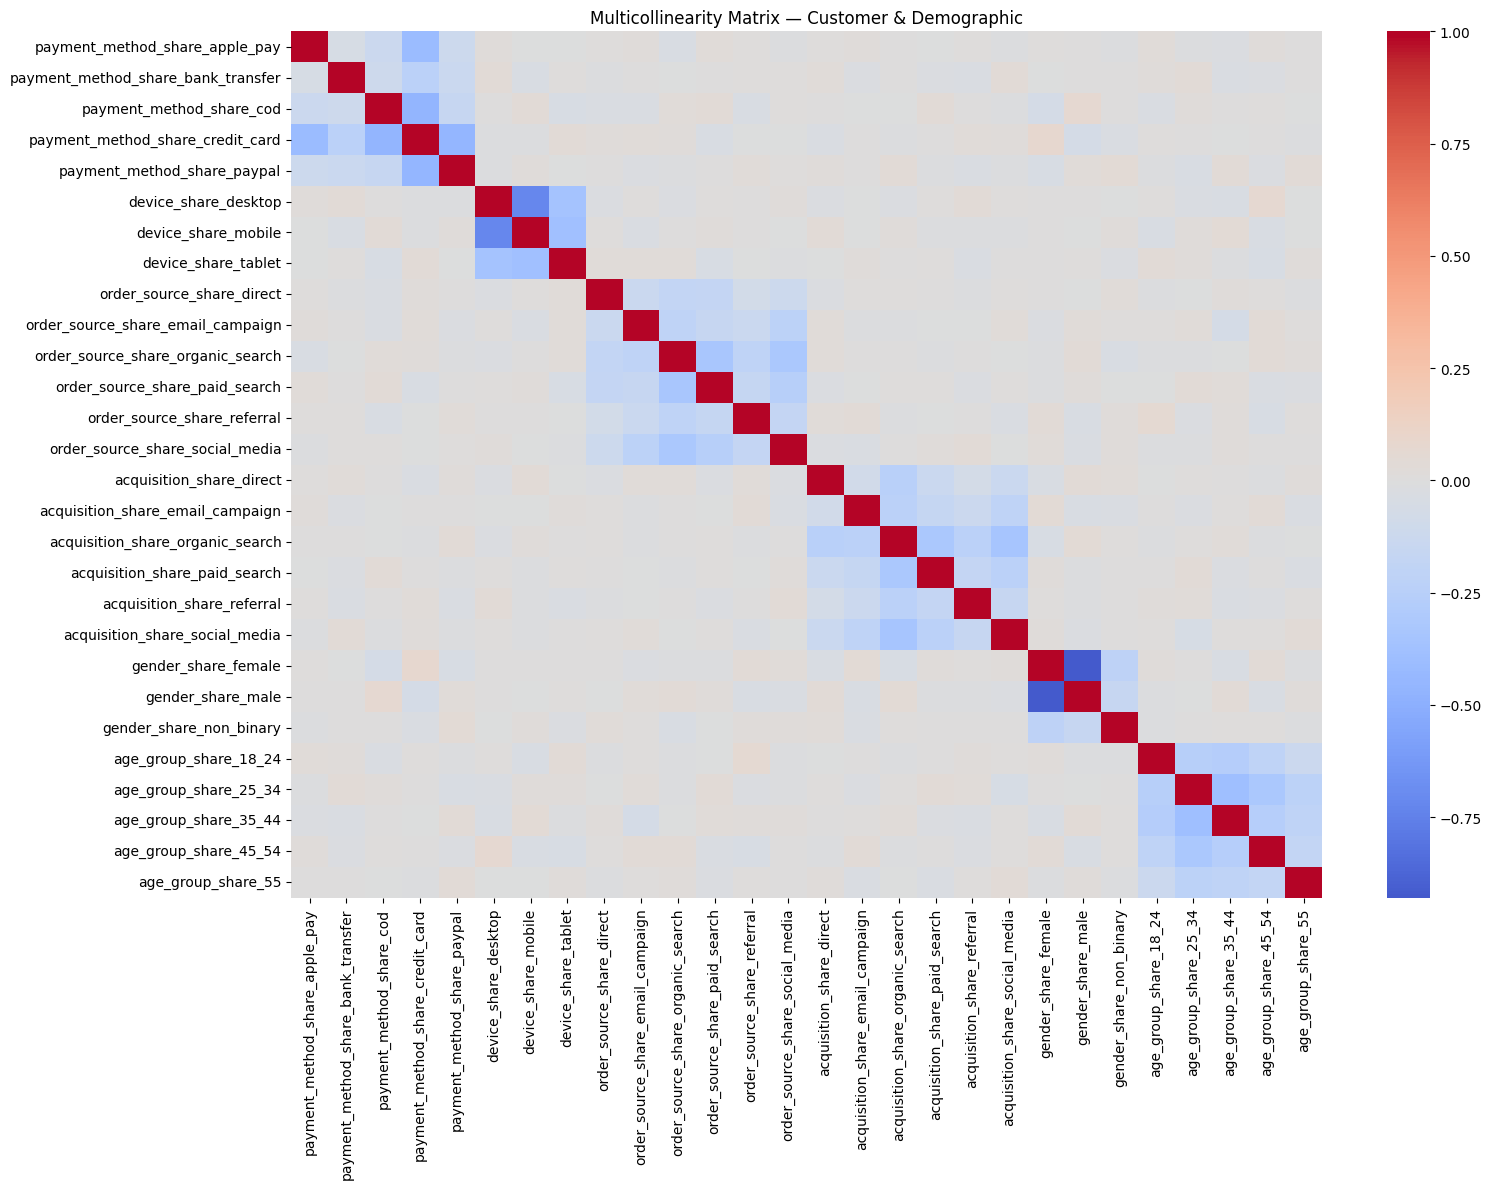

In [8]:
plot_correlation_heatmap(daily_df, customer_cols, group_label="Customer & Demographic")


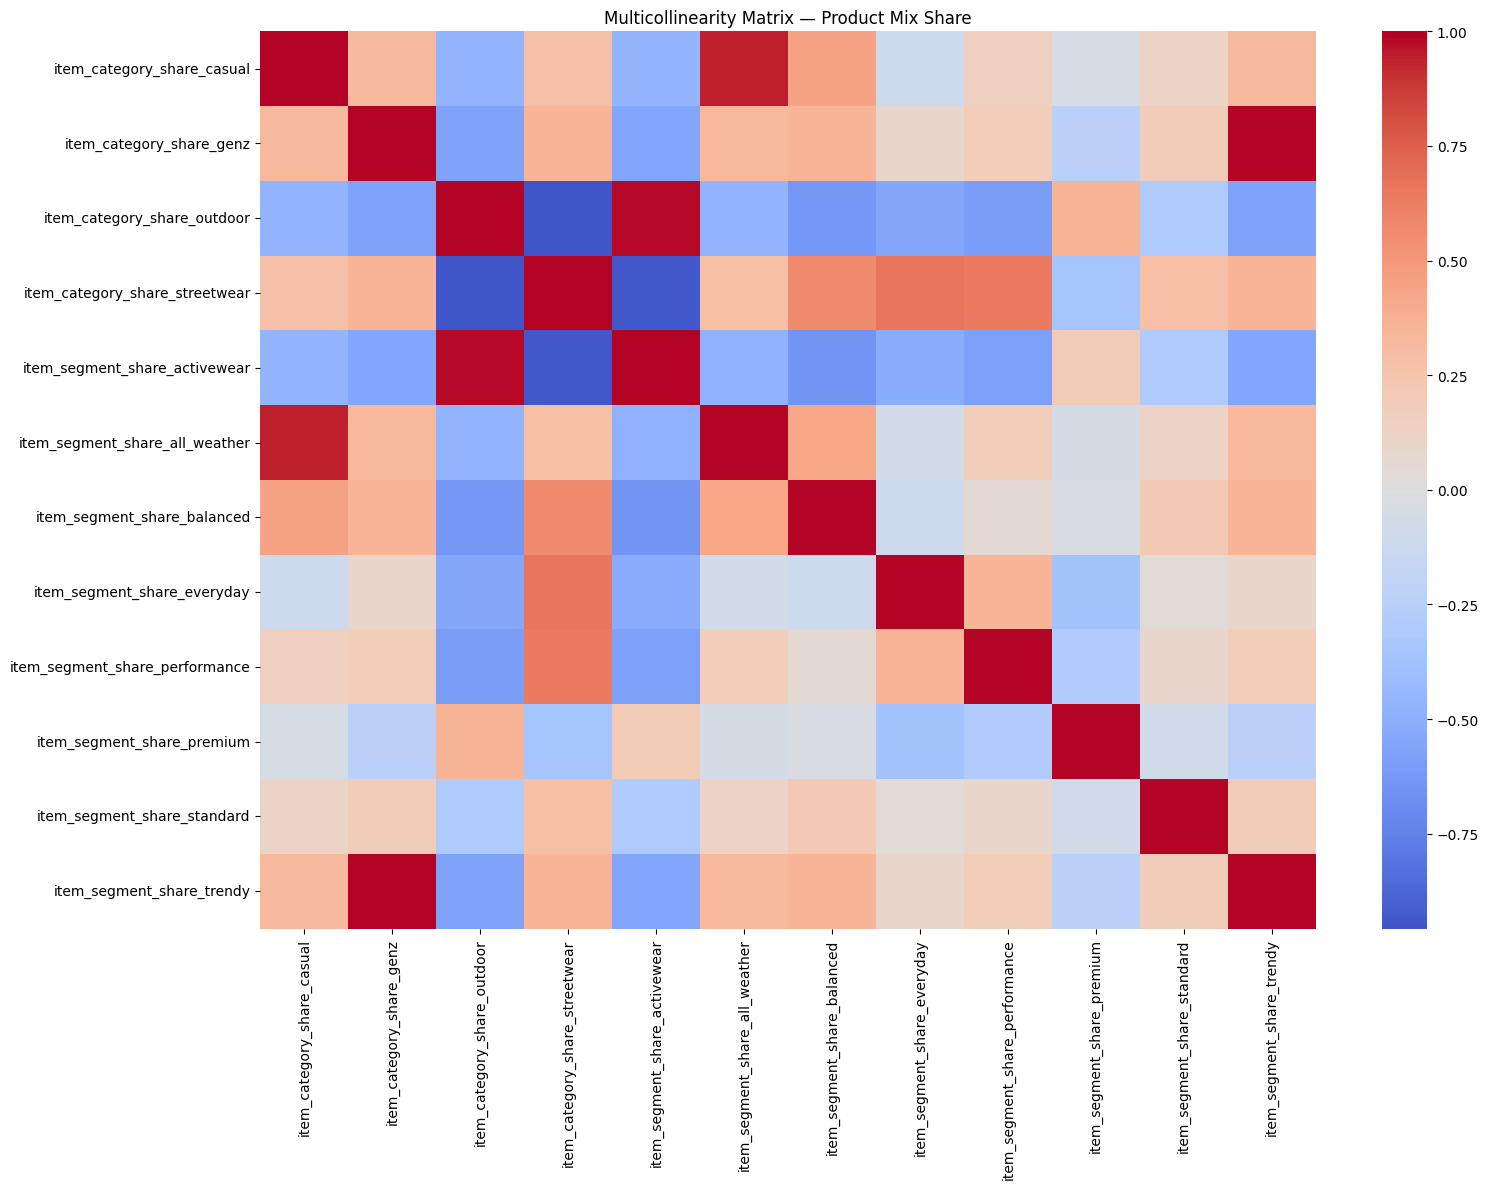

In [9]:
plot_correlation_heatmap(daily_df, product_mix_cols, group_label="Product Mix Share")


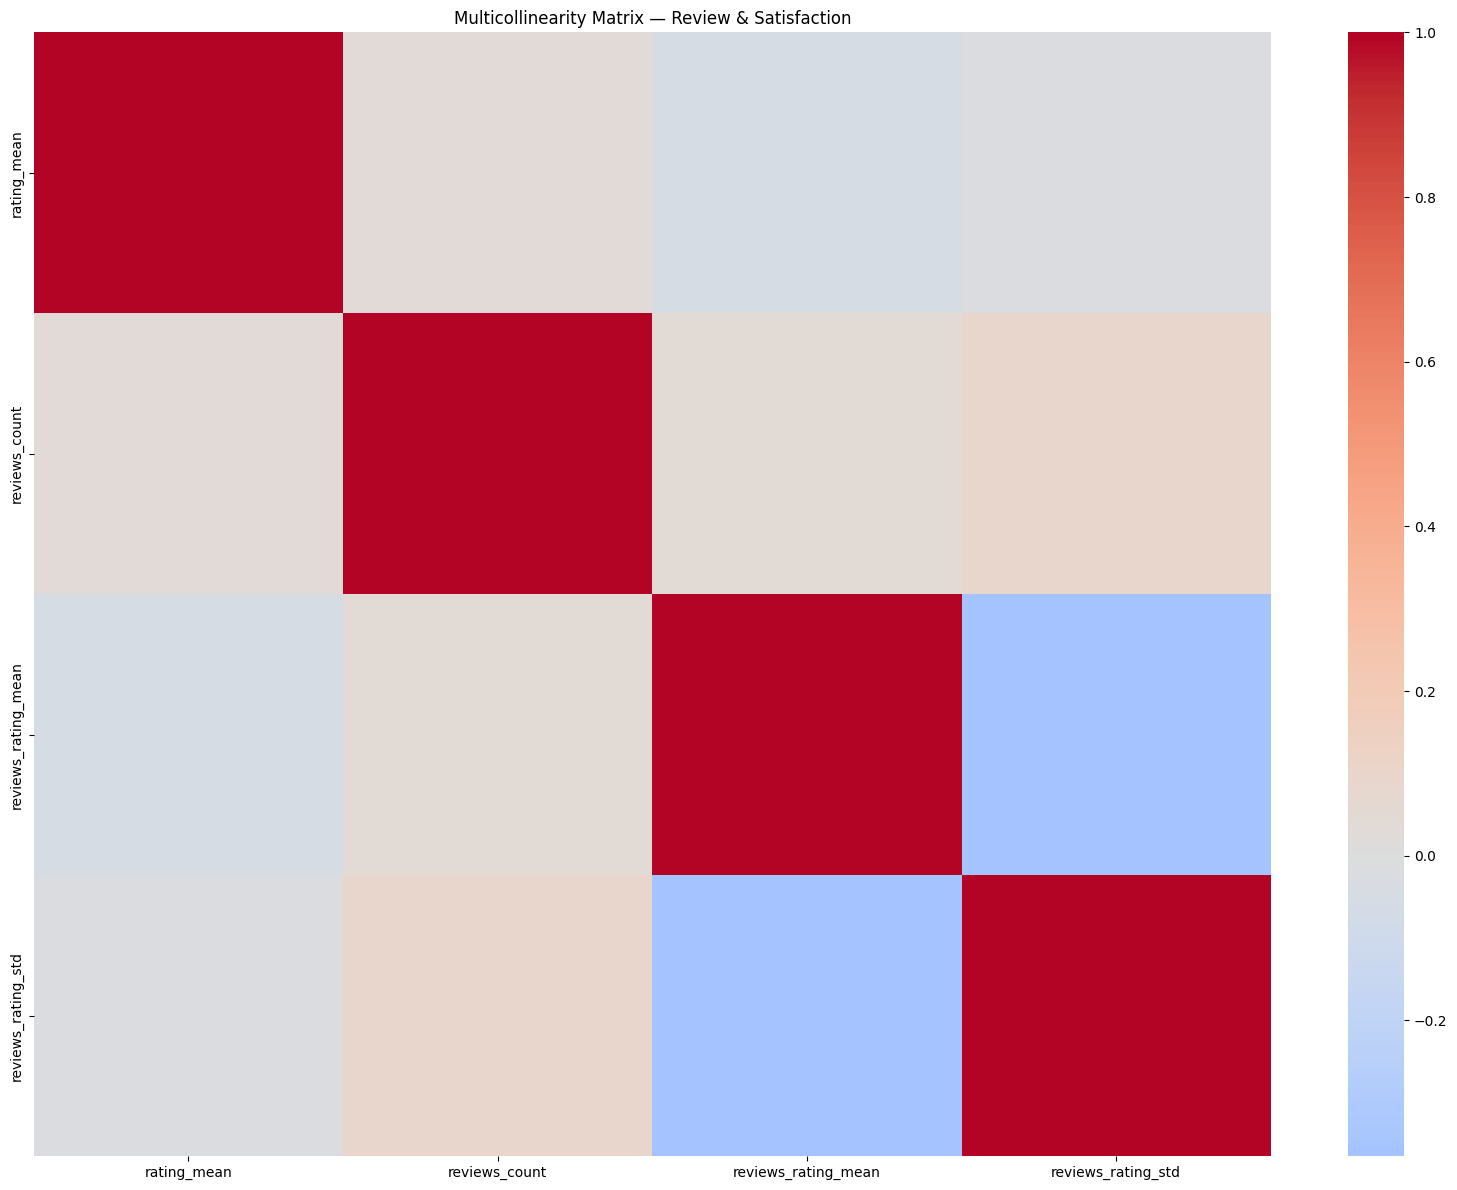

In [10]:
plot_correlation_heatmap(daily_df, review_cols, group_label="Review & Satisfaction")


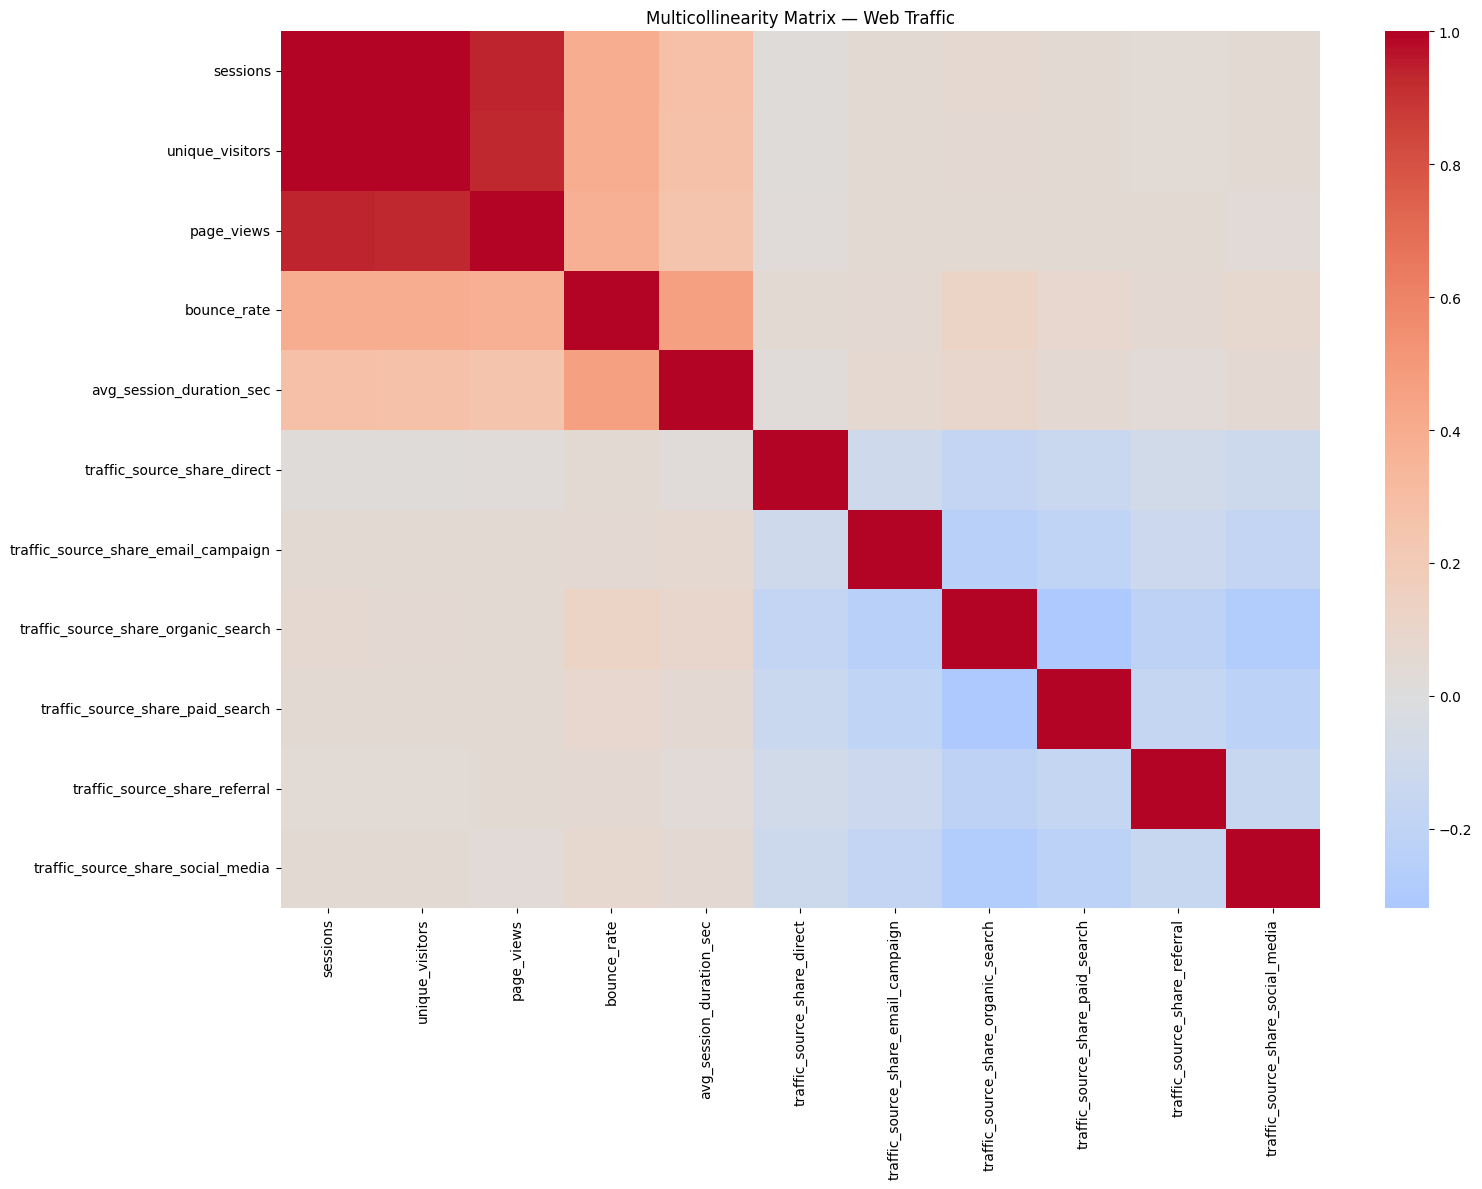

In [11]:
plot_correlation_heatmap(daily_df, web_cols, group_label="Web Traffic")


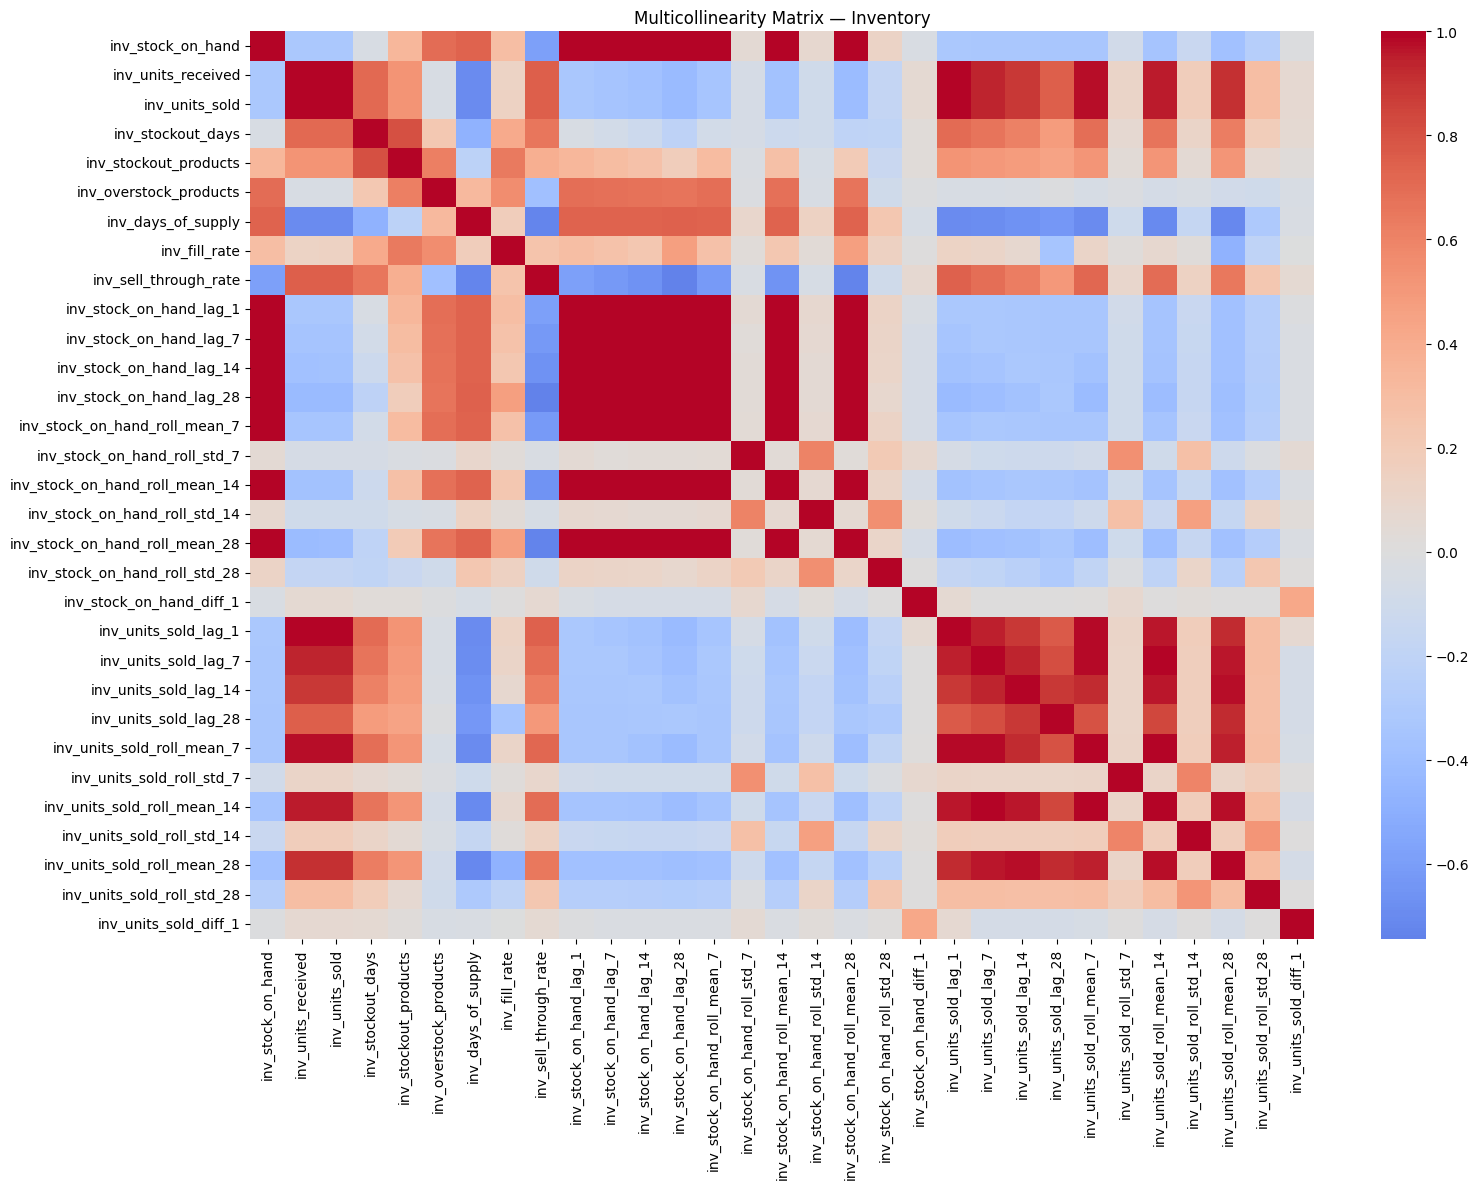

In [12]:
plot_correlation_heatmap(daily_df, inventory_cols, group_label="Inventory")


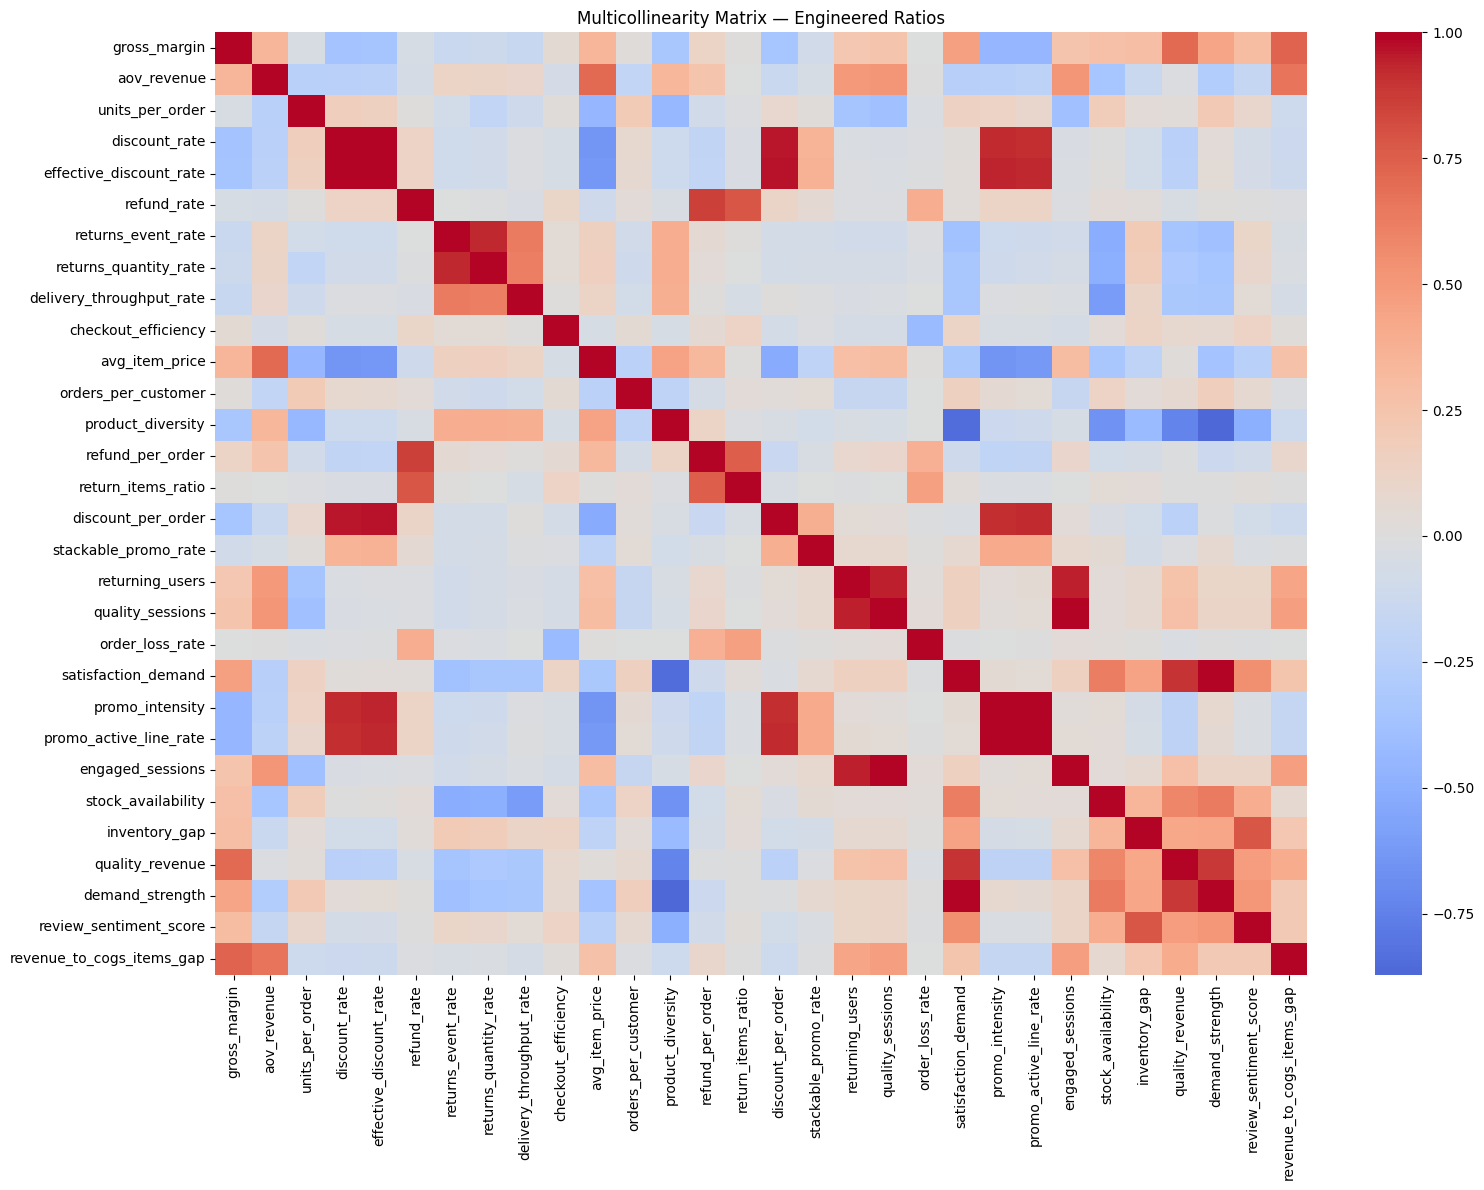

In [13]:
plot_correlation_heatmap(daily_df, engineered_cols, group_label="Engineered Ratios")
